In [1]:
#KERAS FUND with NN


import pandas as pd

import numpy as np


from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,roc_auc_score

import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

from tensorflow.keras.optimizers import SGD

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
df = pd.read_csv(
    filepath_or_buffer='diabetes.csv'
)

df.head()

df.shape

(768, 9)

In [3]:
X = df.iloc[:,:-1].values
y = df['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=42
)

scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

In [4]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=42
)

In [5]:
#Random Forest ML

rf_model = RandomForestClassifier(n_estimators=200)

rf_model.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
y_pred_class_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)

acc_score = accuracy_score(y_test, y_pred_class_rf)
roc_score = roc_auc_score(y_test, y_pred_prob_rf[:, 1])

print(f'Accuracy is {acc_score:.3f}')
print(f'Roc-Auc is {roc_score:.3f}')

Accuracy is 0.747
Roc-Auc is 0.817


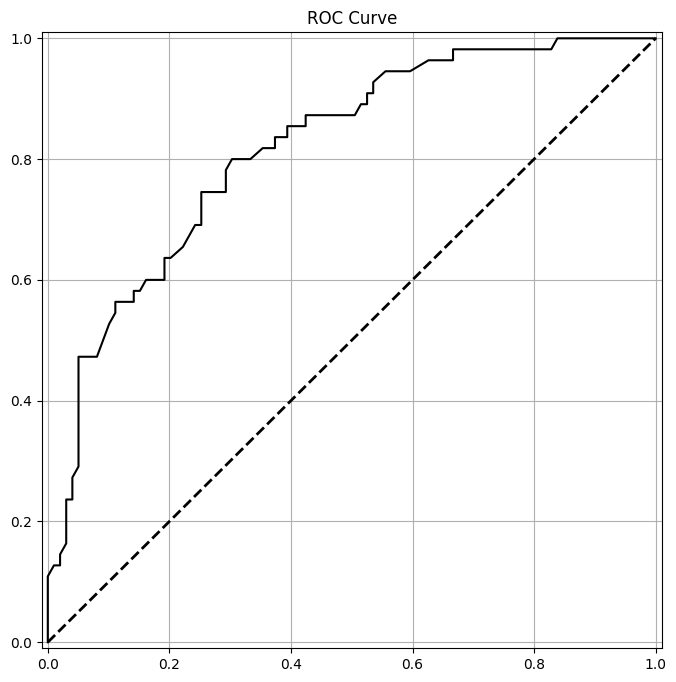

In [ ]:
def plot_roc(y_test, y_pred, model_name):
    fpr, tpr, thr = roc_curve(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(fpr, tpr, 'k-')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2)
    ax.grid(True)
    ax.set(
        title=f'ROC Curve - {model_name}',
        xlim=[-0.01, 1.01],
        ylim=[-0.01, 1.01]
    )

plot_roc(y_test, y_pred_prob_rf[:, 1], 'RF-1')

In [8]:
#prepare_model

model_1 = Sequential()

model_1.add(Dense(units=12, input_shape=(8,), activation='sigmoid'))

model_1.add(Dense(units=1, activation='sigmoid'))

model_1.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 12)                108       
                                                                 
 dense_1 (Dense)             (None, 1)                 13        
                                                                 
Total params: 121 (484.00 Byte)
Trainable params: 121 (484.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
#optimization


model_1.compile(
    optimizer=SGD(learning_rate=0.003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

run_hist_1 = model_1.fit(
    X_train_norm,
    y_train,
    validation_data=(X_test_norm,y_test),
    epochs=200
)

Epoch 1/200


20/20 [==============================] - 1s 15ms/step - loss: 0.7454 - accuracy: 0.3469 - val_loss: 0.7328 - val_accuracy: 0.3571
Epoch 2/200
20/20 [==============================] - 0s 5ms/step - loss: 0.7319 - accuracy: 0.3469 - val_loss: 0.7213 - val_accuracy: 0.3571
Epoch 3/200
20/20 [==============================] - 0s 5ms/step - loss: 0.7206 - accuracy: 0.3469 - val_loss: 0.7110 - val_accuracy: 0.3571
Epoch 4/200
20/20 [==============================] - 0s 5ms/step - loss: 0.7105 - accuracy: 0.3485 - val_loss: 0.7025 - val_accuracy: 0.3636
Epoch 5/200
20/20 [==============================] - 0s 5ms/step - loss: 0.7020 - accuracy: 0.3632 - val_loss: 0.6950 - val_accuracy: 0.4481
Epoch 6/200
20/20 [==============================] - 0s 5ms/step - loss: 0.6945 - accuracy: 0.4186 - val_loss: 0.6884 - val_accuracy: 0.5779
Epoch 7/200
20/20 [==============================] - 0s 5ms/step - loss: 0.6880 - accuracy: 0.6270 - val_loss: 0.6826 - val_accuracy: 0.6688
Epoch 8/20

In [10]:
y_pred_prob_nn_1 = model_1.predict(X_test_norm)
y_pred_class_no_1 = (y_pred_prob_nn_1 > 0.5 ).astype('int32')

print(y_pred_prob_nn_1)
y_pred_class_no_1[:15]

5/5 [==============================] - 0s 4ms/step
[[0.3481385 ]
 [0.34941465]
 [0.35028115]
 [0.35211113]
 [0.34266824]
 [0.34329474]
 [0.34303808]
 [0.36816713]
 [0.34839842]
 [0.34257305]
 [0.3479409 ]
 [0.3447803 ]
 [0.34673998]
 [0.35199887]
 [0.3536213 ]
 [0.35759348]
 [0.34873742]
 [0.3485966 ]
 [0.36859205]
 [0.35617638]
 [0.34086627]
 [0.34213224]
 [0.35437167]
 [0.34816363]
 [0.35259214]
 [0.3551958 ]
 [0.34925988]
 [0.3359765 ]
 [0.34823132]
 [0.3437426 ]
 [0.3652421 ]
 [0.34710637]
 [0.3508559 ]
 [0.37496805]
 [0.34833255]
 [0.35957652]
 [0.35350102]
 [0.34539816]
 [0.3439296 ]
 [0.37342876]
 [0.34734952]
 [0.34512028]
 [0.34581482]
 [0.35666937]
 [0.33777454]
 [0.35268527]
 [0.35308892]
 [0.35334593]
 [0.3466537 ]
 [0.3547676 ]
 [0.34602046]
 [0.34836107]
 [0.3510782 ]
 [0.3536195 ]
 [0.34193724]
 [0.3454005 ]
 [0.34355363]
 [0.34635305]
 [0.35911298]
 [0.35310328]
 [0.35293862]
 [0.3526824 ]
 [0.330701  ]
 [0.35298762]
 [0.34267744]
 [0.35371128]
 [0.34634736]
 [0.3515027

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0]])

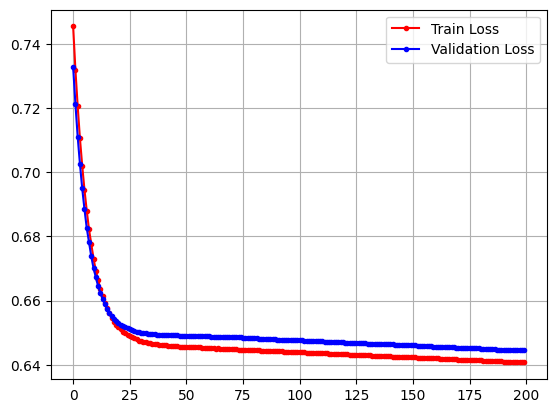

In [11]:
fig, ax = plt.subplots()

ax.plot(
    run_hist_1.history['loss'],
    color='r',
    marker='.',
    label='Train Loss'
)

ax.plot(
    run_hist_1.history['val_loss'],
    color='b',
    marker='.',
    label='Validation Loss'
)

ax.legend()
ax.grid()

In [12]:
run_hist_2 = model_1.fit(
    X_train_norm,
    y_train,
    validation_data=(X_test_norm,y_test),
    epochs=1000
)

Epoch 1/1000
20/20 [==============================] - 0s 7ms/step - loss: 0.6407 - accuracy: 0.6531 - val_loss: 0.6445 - val_accuracy: 0.6429
Epoch 2/1000
20/20 [==============================] - 0s 4ms/step - loss: 0.6407 - accuracy: 0.6531 - val_loss: 0.6444 - val_accuracy: 0.6429
Epoch 3/1000
20/20 [==============================] - 0s 5ms/step - loss: 0.6406 - accuracy: 0.6531 - val_loss: 0.6443 - val_accuracy: 0.6429
Epoch 4/1000
20/20 [==============================] - 0s 5ms/step - loss: 0.6406 - accuracy: 0.6531 - val_loss: 0.6443 - val_accuracy: 0.6429
Epoch 5/1000
20/20 [==============================] - 0s 5ms/step - loss: 0.6405 - accuracy: 0.6531 - val_loss: 0.6443 - val_accuracy: 0.6429
Epoch 6/1000
20/20 [==============================] - 0s 4ms/step - loss: 0.6405 - accuracy: 0.6531 - val_loss: 0.6442 - val_accuracy: 0.6429
Epoch 7/1000
20/20 [==============================] - 0s 5ms/step - loss: 0.6405 - accuracy: 0.6531 - val_loss: 0.6442 - val_accuracy: 0.6429
Epoch 

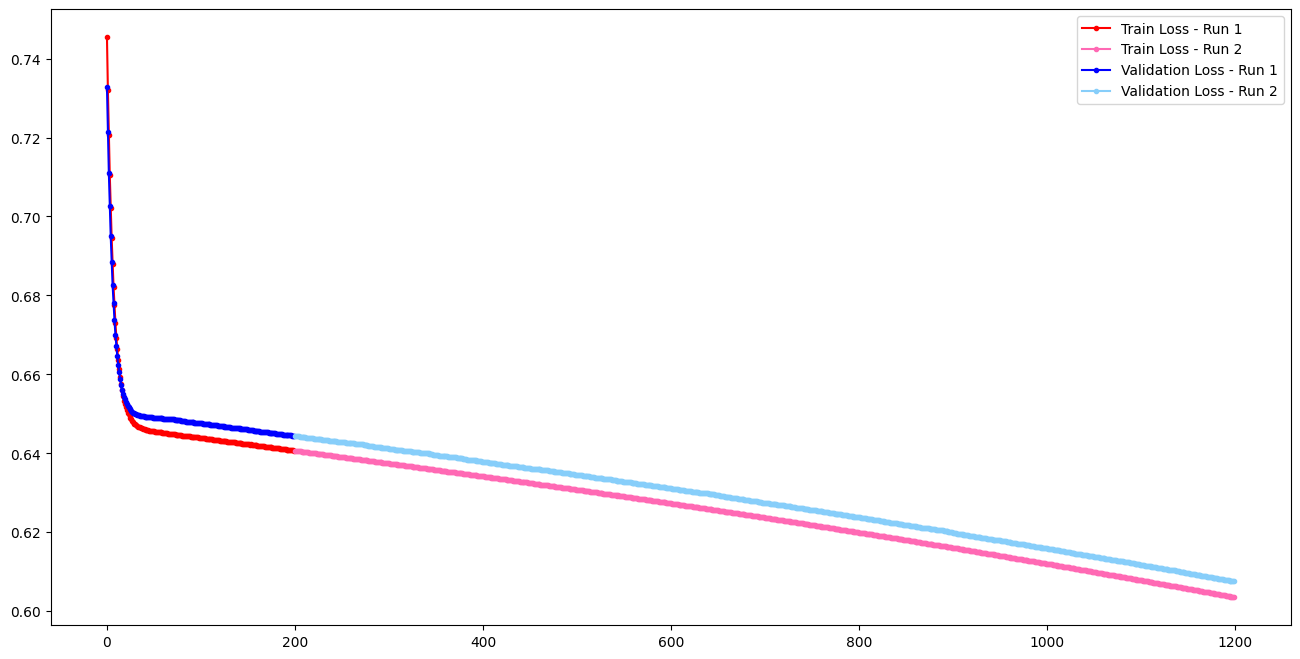

In [13]:
n = len(run_hist_1.history['loss'])
m = len(run_hist_2.history['loss'])

fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(range(n), run_hist_1.history['loss'], color='r', marker='.', label='Train Loss - Run 1')
ax.plot(range(n, n+m), run_hist_2.history['loss'], color='hotpink', marker='.', label='Train Loss - Run 2')

ax.plot(range(n), run_hist_1.history['val_loss'], color='b', marker='.', label='Validation Loss - Run 1')
ax.plot(range(n, n+m), run_hist_2.history['val_loss'], color='LightSkyBlue', marker='.', label='Validation Loss - Run 2')

ax.legend()

In [14]:
model_2 = Sequential()
model_2.add(Dense(6, input_shape=(8,), activation='relu'))
model_2.add(Dense(6, activation='relu'))
model_2.add(Dense(1, activation='sigmoid'))

model_2.compile(
    optimizer=SGD(learning_rate=0.003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

run_hist_2 = model_2.fit(
    X_train_norm,
    y_train,
    validation_data=(X_test_norm, y_test),
    epochs=1500
)

Epoch 1/1500
20/20 [==============================] - 1s 13ms/step - loss: 0.7154 - accuracy: 0.3485 - val_loss: 0.7108 - val_accuracy: 0.3506
Epoch 2/1500
20/20 [==============================] - 0s 5ms/step - loss: 0.7108 - accuracy: 0.3485 - val_loss: 0.7072 - val_accuracy: 0.3377
Epoch 3/1500
20/20 [==============================] - 0s 4ms/step - loss: 0.7070 - accuracy: 0.3648 - val_loss: 0.7036 - val_accuracy: 0.3961
Epoch 4/1500
20/20 [==============================] - 0s 4ms/step - loss: 0.7032 - accuracy: 0.3811 - val_loss: 0.7005 - val_accuracy: 0.4351
Epoch 5/1500
20/20 [==============================] - 0s 4ms/step - loss: 0.6999 - accuracy: 0.4186 - val_loss: 0.6977 - val_accuracy: 0.4740
Epoch 6/1500
20/20 [==============================] - 0s 4ms/step - loss: 0.6970 - accuracy: 0.4463 - val_loss: 0.6949 - val_accuracy: 0.5000
Epoch 7/1500
20/20 [==============================] - 0s 4ms/step - loss: 0.6942 - accuracy: 0.4967 - val_loss: 0.6925 - val_accuracy: 0.5260
Epoch

Text(0.5, 1.0, 'Accuracy Over Iterations')

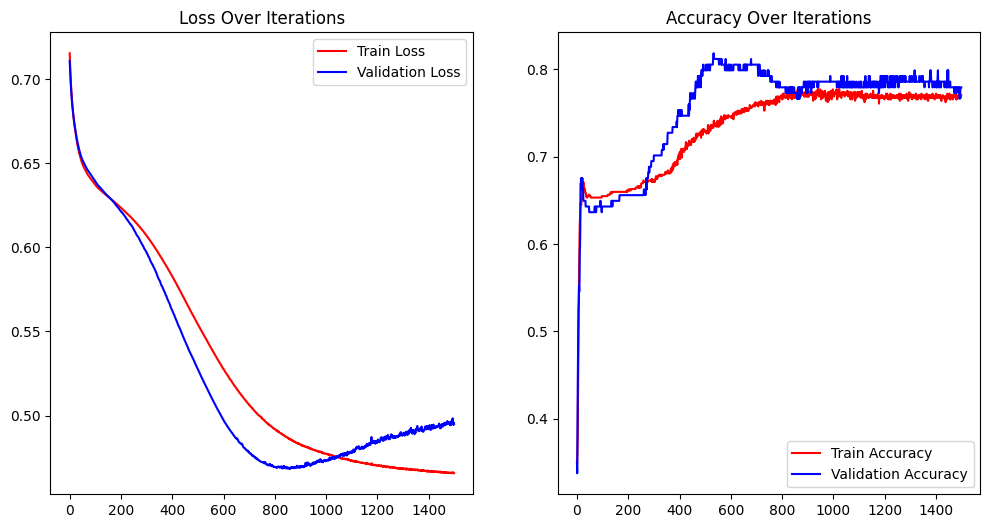

In [15]:
n = len(run_hist_2.history['loss'])

fig = plt.figure(figsize=(12, 6))

ax = fig.add_subplot(1, 2, 1)
ax.plot(range(n), (run_hist_2.history['loss']), color='r', label='Train Loss')
ax.plot(range(n), (run_hist_2.history['val_loss']), color='b', label='Validation Loss')

ax.legend()
ax.set_title('Loss Over Iterations')

ax = fig.add_subplot(1, 2, 2)
ax.plot(range(n), (run_hist_2.history['accuracy']), color='r', label='Train Accuracy')
ax.plot(range(n), (run_hist_2.history['val_accuracy']), color='b', label='Validation Accuracy')

ax.legend(loc='lower right')
ax.set_title('Accuracy Over Iterations')

5/5 [==============================] - 0s 2ms/step
Accuracy Score: 0.78
ROC-AUR: 0.82


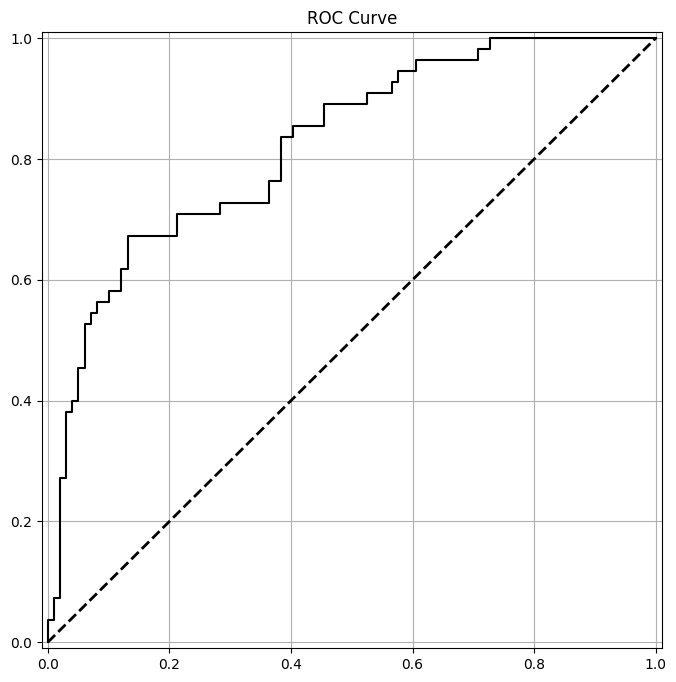

In [ ]:
y_pred_prob_nn_2 = model_2.predict(X_test_norm)
y_pred_class_nn_2 = (y_pred_prob_nn_2 > 0.5).astype('int32')

acc_nn_2 = accuracy_score(y_test, y_pred_class_nn_2)
roc_auc_2 = roc_auc_score(y_test, y_pred_prob_nn_2)

print(
    f'Accuracy Score: {acc_nn_2:.2f}\n'
    f'ROC-AUC: {roc_auc_2:.2f}'
)

plot_roc(y_test, y_pred_prob_nn_2, 'NN-2')